# AI Email Triage Agent: Unsloth Fine-Tuning

This notebook trains a Llama-3 model using Unsloth and Hugging Face TRL to act as our Email Triage Agent. It is designed to be run in Google Colab.


In [1]:
import warnings
warnings.filterwarnings("ignore")
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-7y2kykli/unsloth_32e914d2025349c8acac16b4a17ae0fe
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-7y2kykli/unsloth_32e914d2025349c8acac16b4a17ae0fe
  Resolved https://github.com/unslothai/unsloth.git to commit efed5c37394a144349cd9b1ea525e132e04584e5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 21.4 MB/s eta 0:00:0

In [2]:
from unsloth import FastLanguageModel
import torch
max_seq_length = 2048 # Choose any! We auto support RoPE Scaling internally!
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = True # Use 4bit quantization to reduce memory usage. Can be False.

# 1. Load the model
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/llama-3-8b-Instruct-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# 2. Add LoRA adapters
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/220 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/345 [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3-8b-Instruct-bnb-4bit as a legacy tokenizer.
Unsloth 2026.4.8 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


## Dataset Preparation
We create a simulated dataset to teach the agent to output the precise JSON formats required by `OpenEnv`.

In [3]:
from datasets import Dataset
import json

# Sample dataset mimicking the EmailEnv requirements
data = [
    {
        "subject": "Win a FREE iPhone now!!!",
        "body": "Click this link to claim your prize before it's too late!",
        "decision": "spam",
        "reply_text": None,
        "confidence_score": 0.95
    },
    {
        "subject": "Issue with my order #1234",
        "body": "I was charged twice. Please help.",
        "decision": "reply",
        "reply_text": "I apologize for the issue. I have initiated a refund for the duplicate charge.",
        "confidence_score": 0.88
    },
    {
        "subject": "Server down!!!",
        "body": "Production server is not responding!",
        "decision": "escalate",
        "reply_text": None,
        "confidence_score": 0.92
    },
    {
        "subject": "Unclear request",
        "body": "Please process it as discussed. I need this done ASAP but I forgot the details.",
        "decision": "needs_human_review",
        "reply_text": None,
        "confidence_score": 0.45
    }
]

dataset = Dataset.from_list(data)

In [4]:
prompt_template = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an AI email triage agent.

RULES:
1. Decide the best action: spam, archive, reply, escalate, needs_human_review.
2. If the action is 'reply', you MUST draft a polite, helpful response.
3. If the action is 'escalate', you MUST NOT write a reply. Leave it empty.
4. CONFIDENCE SCORING: You must calculate a genuine confidence_score between 0.0 and 1.0.
You MUST respond ONLY with valid JSON.
<|eot_id|><|start_header_id|>user<|end_header_id|>
CURRENT EMAIL:
Subject: {subject}
Body: {body}
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
{output}<|eot_id|>"""

EOS_TOKEN = tokenizer.eos_token
def formatting_prompts_func(examples):
    subjects = examples["subject"]
    bodies = examples["body"]
    decisions = examples["decision"]
    replies = examples["reply_text"]
    scores = examples["confidence_score"]

    texts = []
    for sub, body, dec, rep, sc in zip(subjects, bodies, decisions, replies, scores):
        # Format expected JSON
        output_dict = {
            "decision": dec,
            "reply_text": rep,
            "confidence_score": sc
        }
        output_json = json.dumps(output_dict, indent=4)

        # Inject into prompt template
        text = prompt_template.format(subject=sub, body=body, output=output_json) + EOS_TOKEN
        texts.append(text)
    return { "text" : texts, }

formatted_dataset = dataset.map(formatting_prompts_func, batched = True)


Map:   0%|          | 0/4 [00:00<?, ? examples/s]

## Training
Using SFTTrainer from Hugging Face `trl`.

In [5]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = formatted_dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = False, # Can make training 5x faster for short sequences.
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60, # Increase this for real training (e.g. use num_train_epochs)
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)

trainer_stats = trainer.train()

num_proc must be <= 4. Reducing num_proc to 4 for dataset of size 4.


Unsloth: Tokenizing ["text"] (num_proc=4):   0%|          | 0/4 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 4 | Num Epochs = 60 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
1,3.521617
2,3.521617
3,3.339267
4,2.923409
5,2.529480
6,2.156737
7,1.745285
8,1.377451
9,0.995540
10,0.689591


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-60/tokenizer_config.json.


## Visualizing Training Loss
Let's plot the training loss curve and save it as an image for our hackathon submission evidence.

✅ Training loss plot saved as 'training_loss_plot.png'!


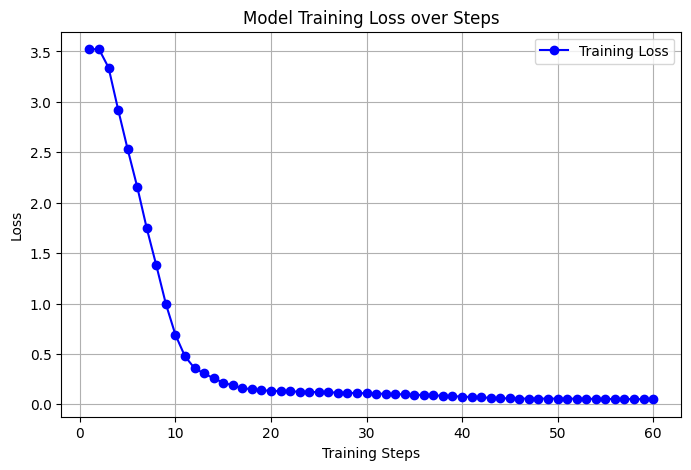

In [6]:
import matplotlib.pyplot as plt

# Extract the loss values from the trainer's state
loss_history = [log["loss"] for log in trainer.state.log_history if "loss" in log]
steps = [log["step"] for log in trainer.state.log_history if "loss" in log]

plt.figure(figsize=(8, 5))
plt.plot(steps, loss_history, label="Training Loss", color="blue", marker="o")
plt.title("Model Training Loss over Steps")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Save the graph as an image file
plt.savefig("training_loss_plot.png", dpi=300, bbox_inches="tight")
print("✅ Training loss plot saved as 'training_loss_plot.png'!")

plt.show()

## Inference and Saving
Let's test the model and save the adapter weights.

In [7]:
FastLanguageModel.for_inference(model) # Enable native 2x faster inference

test_prompt = prompt_template.format(
    subject="Urgent: System crash detected",
    body="The main database node has gone offline and users cannot log in.",
    output="" # Leave empty for the model to generate
)

inputs = tokenizer([test_prompt], return_tensors = "pt").to("cuda")
outputs = model.generate(**inputs, max_new_tokens = 64, use_cache = True)
print(tokenizer.batch_decode(outputs, skip_special_tokens = True)[0])

Both `max_new_tokens` (=64) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


system
You are an AI email triage agent.

RULES:
1. Decide the best action: spam, archive, reply, escalate, needs_human_review.
2. If the action is'reply', you MUST draft a polite, helpful response.
3. If the action is 'escalate', you MUST NOT write a reply. Leave it empty.
4. CONFIDENCE SCORING: You must calculate a genuine confidence_score between 0.0 and 1.0.
You MUST respond ONLY with valid JSON.
user
CURRENT EMAIL:
Subject: Urgent: System crash detected
Body: The main database node has gone offline and users cannot log in.
assistant
action": "escalate",
"reply_text": null,
"confidence_score": 0.92
}


In [8]:
# Save LoRA adapter locally
model.save_pretrained("lora_email_triage_model")
tokenizer.save_pretrained("lora_email_triage_model")

# Push to Hugging Face Hub (uncomment and replace with your token)
# model.push_to_hub("your_name/lora_email_triage_model", token = "...")
# tokenizer.push_to_hub("your_name/lora_email_triage_model", token = "...")

Unsloth: Restored added_tokens_decoder metadata in lora_email_triage_model/tokenizer_config.json.


('lora_email_triage_model/tokenizer_config.json',
 'lora_email_triage_model/chat_template.jinja',
 'lora_email_triage_model/tokenizer.json')